 environment config

In [8]:

import pandas as pd
import json
import re
import emoji
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

try:
    word_tokenize("test string") 
except LookupError:
    print("NLTK 'punkt' not found. Downloading...")
    nltk.download('punkt', quiet=True)
    print("'punkt' downloaded.")

try:
    stopwords.words('english')
except LookupError:
    print("NLTK 'stopwords' not found. Downloading...")
    nltk.download('stopwords', quiet=True)
    print("'stopwords' downloaded.")

NLTK 'punkt' not found. Downloading...
'punkt' downloaded.


In [9]:
# Loading dataset
def load_json_data(file_path):
    """加载JSON文件"""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

print("load_json_data defined")

load_json_data defined


In [10]:
# clean tweets, removing URLs, mentions, hashtags, emojis, and non-Latin characters
import emoji
import re

def clean_tweet(text):
    # lowercase
    text = str(text).lower() 
    
    # 1. remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # 3. remove hashtags but keep the text
    text = re.sub(r'#', '', text)
    
    # 4. remove emojis
    text = emoji.demojize(text, delimiters=(" emoji_", "_emoji "))
    text = re.sub(r' emoji_.*?_emoji ', ' ', text)
    
    # 5. remove non-Latin characters and keep basic punctuation
    text = re.sub(r'[^a-z0-9\s.!?,\u00E1\u00E9\u00ED\u00F3\u00FA\u00F1\u00FC]', '', text)
    
    # 6. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("clean_tweet")

clean_tweet


In [11]:
# process_data function to handle the entire dataset
def process_data(file_path):
    """处理整个数据集"""
    # 读取数据
    raw_data = load_json_data(file_path)
    
    tweets_list = [] # initialize an empty list to hold tweet objects
    
    if isinstance(raw_data, dict):
        tweets_list = list(raw_data.values())
        if not tweets_list:
             raise ValueError("JSON顶层字典的值为空，无法提取推文列表。")
        print(f"从顶层字典的值中提取了 {len(tweets_list)} 个条目作为推文。")
    elif isinstance(raw_data, list): 
        tweets_list = raw_data
        if not tweets_list:
            raise ValueError("JSON顶层列表为空。")
        print("JSON顶层直接是一个列表，将其用作推文列表。")
    else:
        raise ValueError(f"无法识别的JSON数据结构。顶层既不是预期的字典也不是列表，而是类型: {type(raw_data)}")
            
    if not tweets_list: # 双重检查
        raise ValueError("未能从JSON数据中成功提取推文列表。")
            
    df = pd.DataFrame(tweets_list)
    
    text_column_to_use = None
    possible_text_columns = ['tweet', 'text', 'text_es', 'text_en', 'tweet_text', 'full_text'] 
    
    print(f"\nDataFrame的列名: {list(df.columns)}")

    for col in possible_text_columns:
        if col in df.columns:
            text_column_to_use = col
            print(f"使用列 '{text_column_to_use}' 作为推文文本。")
            break
            
    if text_column_to_use is None:
        raise ValueError(f"DataFrame中未找到合适的文本列 (已尝试: {possible_text_columns})。" \
                         f" 请检查DataFrame的列: {list(df.columns)} 并更新possible_text_columns。")
            
    tqdm.pandas(desc="清理推文")
    df[text_column_to_use] = df[text_column_to_use].astype(str)
    df['cleaned_text'] = df[text_column_to_use].progress_apply(clean_tweet)
    
    return df, text_column_to_use

print("process_data 函数已更新。")

process_data 函数已更新。


In [12]:
# 调试单元格：检查JSON结构
debug_file_path = "/Users/zenanjin/Study/德语TUM/sexism/nlp_practical_2025_sEXism/2025 EXIST/EXIST 2025 Tweets Dataset/dev/EXIST2025_dev.json"
raw_data_debug = None
print(f"正在尝试加载调试文件: {debug_file_path}")
try:
    with open(debug_file_path, 'r', encoding='utf-8') as f:
        raw_data_debug = json.load(f)
    
    print("文件加载成功。")

    if isinstance(raw_data_debug, dict):
        print("JSON顶层是一个字典。以下是它的键 (keys):")
        print(list(raw_data_debug.keys()))
        
        print("\n详细检查每个键对应的值:")
        for key, value in raw_data_debug.items():
            print(f"--- 键: '{key}' ---")
            print(f"  值的类型: {type(value)}")
            if isinstance(value, list):
                print(f"  这是一个列表，其长度为: {len(value)}")
                if len(value) > 0:
                    print(f"  列表的前1个元素是:")
                    item = value[0]
                    print(f"    元素 0 类型: {type(item)}")
                    if isinstance(item, dict):
                        print(f"    元素 0 是一个字典，其键为: {list(item.keys())}")
                        # 尝试打印可能包含文本的键
                        possible_text_keys_in_item = ['tweet', 'text', 'text_es', 'text_en', 'content', 'message']
                        for p_key in possible_text_keys_in_item:
                            if p_key in item:
                                print(f"      预览 '{p_key}': {str(item[p_key])[:100]}...")
                                break
                    else:
                        print(f"    元素 0 (前100字符): {str(item)[:100]}...")
                else:
                    print("  列表为空。")
            elif isinstance(value, dict):
                 print(f"  这是一个字典，其键为: {list(value.keys())}")
            else:
                print(f"  值 (前100字符): {str(value)[:100]}...")
            print("-" * 20)

    elif isinstance(raw_data_debug, list):
        print("JSON顶层是一个列表。")
        print(f"列表长度为: {len(raw_data_debug)}")
        if len(raw_data_debug) > 0:
            print(f"列表的前1个元素是:")
            item = raw_data_debug[0]
            print(f"  元素 0 类型: {type(item)}")
            if isinstance(item, dict):
                print(f"  元素 0 是一个字典，其键为: {list(item.keys())}")
                possible_text_keys_in_item = ['tweet', 'text', 'text_es', 'text_en', 'content', 'message']
                for p_key in possible_text_keys_in_item:
                    if p_key in item:
                        print(f"      预览 '{p_key}': {str(item[p_key])[:100]}...")
                        break
            else:
                print(f"  元素 0 (前100字符): {str(item)[:100]}...")
        else:
            print("列表为空。")
    else:
        print(f"JSON顶层既不是字典也不是列表，而是类型: {type(raw_data_debug)}")

except FileNotFoundError:
    print(f"错误：找不到文件 {debug_file_path}")
except json.JSONDecodeError as e:
    print(f"错误：JSON文件解码失败 - {e}")
except Exception as e:
    import traceback
    print(f"发生未知错误: {e}")
    print(traceback.format_exc())

正在尝试加载调试文件: /Users/zenanjin/Study/德语TUM/sexism/nlp_practical_2025_sEXism/2025 EXIST/EXIST 2025 Tweets Dataset/dev/EXIST2025_dev.json
文件加载成功。
JSON顶层是一个字典。以下是它的键 (keys):
['300001', '300002', '300003', '300004', '300005', '300006', '300007', '300008', '300009', '300010', '300011', '300012', '300013', '300014', '300015', '300016', '300017', '300018', '300019', '300020', '300021', '300022', '300023', '300024', '300025', '300026', '300027', '300028', '300029', '300030', '300031', '300032', '300033', '300034', '300035', '300036', '300037', '300038', '300039', '300040', '300041', '300042', '300043', '300044', '300045', '300046', '300047', '300048', '300049', '300050', '300051', '300052', '300053', '300054', '300055', '300056', '300057', '300058', '300059', '300060', '300061', '300062', '300063', '300064', '300065', '300066', '300067', '300068', '300069', '300070', '300071', '300072', '300073', '300074', '300075', '300076', '300077', '300078', '300079', '300080', '300081', '300082', '300083', '

In [13]:
train_file_path = "/Users/zenanjin/Study/德语TUM/sexism/nlp_practical_2025_sEXism/2025 EXIST/EXIST 2025 Tweets Dataset/dev/EXIST2025_dev.json"

train_df = None 
original_text_column_name = None 

try:
    train_df, original_text_column_name = process_data(train_file_path)
    
    print("\n数据集基本信息：")
    train_df.info()
    
    if original_text_column_name:
        print("\n数据示例 (前5条)：")
        print(train_df[[original_text_column_name, 'cleaned_text']].head())
    else:
        print("\n警告: 未能确定原始文本列名，无法显示清理前后对比。")
        print(train_df[['cleaned_text']].head()) # 只显示清理后的文本
    
    empty_cleaned_text_count = train_df[train_df['cleaned_text'] == ''].shape[0]
    if empty_cleaned_text_count > 0:
        print(f"\n警告：有 {empty_cleaned_text_count} 条推文在清理后文本内容为空。")
            
except FileNotFoundError:
    print(f"错误：找不到文件 {train_file_path}。请检查文件路径是否正确。")
except ValueError as e:
    print(f"处理数据时发生值错误: {e}")
except Exception as e:
    import traceback
    print(f"发生未知错误: {e}")
    print(traceback.format_exc())

从顶层字典的值中提取了 1038 个条目作为推文。

DataFrame的列名: ['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'ethnicities_annotators', 'study_levels_annotators', 'countries_annotators', 'labels_task1_1', 'labels_task1_2', 'labels_task1_3', 'split']
使用列 'tweet' 作为推文文本。


清理推文: 100%|██████████| 1038/1038 [00:00<00:00, 12964.97it/s]


数据集基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_EXIST                 1038 non-null   object
 1   lang                     1038 non-null   object
 2   tweet                    1038 non-null   object
 3   number_annotators        1038 non-null   int64 
 4   annotators               1038 non-null   object
 5   gender_annotators        1038 non-null   object
 6   age_annotators           1038 non-null   object
 7   ethnicities_annotators   1038 non-null   object
 8   study_levels_annotators  1038 non-null   object
 9   countries_annotators     1038 non-null   object
 10  labels_task1_1           1038 non-null   object
 11  labels_task1_2           1038 non-null   object
 12  labels_task1_3           1038 non-null   object
 13  split                    1038 non-null   object
 14  cleaned_text             1038 

In [14]:
# 单元格 11: 检查并保存清理后的数据 (保留所有原始列)

# 确保 train_df 已成功创建并且包含 cleaned_text 列
if 'train_df' in locals() and train_df is not None and 'cleaned_text' in train_df.columns:
    output_file_path = "cleaned_dev_EXIST2025_training.csv"
    
    try:
        print("\nDataFrame中的所有列名:")
        print(list(train_df.columns))
        
        print("\n准备保存的DataFrame (前5行，展示部分重要列和清理后的文本):")
        columns_to_preview = []
        if 'id' in train_df.columns:
            columns_to_preview.append('id')
        
        if 'original_text_column_name' in locals() and original_text_column_name in train_df.columns:
            columns_to_preview.append(original_text_column_name)
        elif 'tweet' in train_df.columns:
            columns_to_preview.append('tweet')
        elif 'text' in train_df.columns:
            columns_to_preview.append('text')

        columns_to_preview.append('cleaned_text')

        if 'label' in train_df.columns:
            columns_to_preview.append('label')
        
        columns_to_preview = [col for col in columns_to_preview if col in train_df.columns]
        
        if columns_to_preview:
            print(train_df[columns_to_preview].head())
        else:
            print("无法自动确定要预览的列，打印整个DataFrame的前5行：")
            print(train_df.head())

        # 保存为 utf-8-sig 编码，以便 Excel 正确读取
        train_df.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"\n清理后的数据已成功保存到: {output_file_path}")
        print(f"完整路径: /Users/zenanjin/Study/德语TUM/sexism/nlp_practical_2025_sEXism/{output_file_path}")

    except Exception as e:
        print(f"\n保存CSV文件时出错: {e}")
        import traceback
        print(traceback.format_exc())

elif 'train_df' in locals() and train_df is None:
    print("\n错误：train_df 是 None。无法保存数据。")
elif 'train_df' not in locals():
    print("\n错误：train_df 变量不存在。请确保已运行前面的数据加载和清理步骤。")
else:
    print(f"\n错误：'cleaned_text' 列不存在于 train_df 中。现有列: {train_df.columns}")

print("\n单元格11执行完毕。")


DataFrame中的所有列名:
['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators', 'gender_annotators', 'age_annotators', 'ethnicities_annotators', 'study_levels_annotators', 'countries_annotators', 'labels_task1_1', 'labels_task1_2', 'labels_task1_3', 'split', 'cleaned_text']

准备保存的DataFrame (前5行，展示部分重要列和清理后的文本):
                                               tweet  \
0  @Fichinescu La comunidad gamer es un antro de ...   
1  @anacaotica88 @MordorLivin No me acuerdo de lo...   
2  @cosmicJunkBot lo digo cada pocos dias y lo re...   
3  Also mientras les decia eso la señalaba y deci...   
4  And all people killed,  attacked, harassed by ...   

                                        cleaned_text  
0  la comunidad gamer es un antro de misóginos y ...  
1  no me acuerdo de los detalles de gamergate, pe...  
2  lo digo cada pocos dias y lo repito todo esto ...  
3  also mientras les decia eso la señalaba y deci...  
4  and all people killed, attacked, harassed by c...  

清理后的数据已成功保存到: cl

Data augmentation

In [10]:
# 单元格 12: AEDA 增强
import random

def aeda_augment(text, punctuations=None, ratio=0.3):
    """
    对输入文本执行 AEDA 数据增强：在随机位置插入标点。
    """
    if punctuations is None:
        punctuations = ['.', ',', ';', '!', '?', ':']
    
    words = text.split()
    if len(words) < 2:
        return text  # 不增强过短文本

    n_punc = max(1, int(len(words) * ratio))

    for _ in range(n_punc):
        insert_idx = random.randint(0, len(words))
        punc = random.choice(punctuations)
        words.insert(insert_idx, punc)

    return ' '.join(words)

# 应用 AEDA 增强
if 'train_df' in locals() and 'cleaned_text' in train_df.columns:
    tqdm.pandas(desc="AEDA增强中")
    train_df['aug_aeda'] = train_df['cleaned_text'].progress_apply(lambda x: aeda_augment(x, ratio=0.3))

    # 展示部分增强示例
    print("\n原始与AEDA增强对比示例：")
    print(train_df[['cleaned_text', 'aug_aeda']].sample(5))
else:
    print("错误：未找到 train_df 或 'cleaned_text' 列，无法执行 AEDA 增强。")
    
print(train_df.columns)

AEDA增强中: 100%|██████████| 6920/6920 [00:00<00:00, 132048.17it/s]


原始与AEDA增强对比示例：
                                           cleaned_text  \
2363  me fui a comprar y uno me grito que pechos mam...   
3699  you have rage issues that manifest in an inter...   
6864  to the guy who beeped at me after id put my ha...   
4698  since when has a woman stopped being defined a...   
6166  its also funny we tell women to be patient and...   

                                               aug_aeda  
2363  , me fui a comprar ? y uno me grito que pechos...  
3699  ; ! : ? you have ! rage issues ? that manifest...  
6864  to the guy who beeped ; at me , , after id put...  
4698  since when has a woman : stopped being . defin...  
6166  : its also funny we tell women to be patient a...  
Index(['id_EXIST', 'lang', 'tweet', 'number_annotators', 'annotators',
       'gender_annotators', 'age_annotators', 'ethnicities_annotators',
       'study_levels_annotators', 'countries_annotators', 'labels_task1_1',
       'labels_task1_2', 'labels_task1_3', 'split', 'cleaned_t

In [11]:
# 单元格 13（可选）: 合并原始与AEDA数据
if 'aug_aeda' in train_df.columns:
    df_orig = train_df[['cleaned_text']].rename(columns={'cleaned_text': 'text'})
    df_aug = train_df[['aug_aeda']].rename(columns={'aug_aeda': 'text'})
    df_combined = pd.concat([df_orig, df_aug], ignore_index=True)
    print(f"\n合并后的训练集大小: {len(df_combined)} 行")
    print(df_combined.sample(5))
else:
    print("无法构建合并数据，缺少增强列或标签列。")


合并后的训练集大小: 13840 行
                                                    text
4970                   girl go to hell ! leave her alone
8846   interseccionalidad? ... eso qué es, estar : , ...
10737  on ! ; the ! ; anniversary of women gaining th...
4751   its called a blocklist. its so people that wan...
8192   ? en las protestas . ; recientes vi mujeres mo...


In [12]:
# 假设train_df已经有cleaned_text和aug_aeda，以及你所有的原始字段
import pandas as pd

# 1. 构建原始数据部分
df_cleaned = train_df.copy()
df_cleaned['text'] = df_cleaned['cleaned_text']
df_cleaned['source'] = 'cleaned'

# 2. 构建AEDA增强部分
df_aeda = train_df.copy()
df_aeda['text'] = df_aeda['aug_aeda']
df_aeda['source'] = 'aeda'

# 3. 拼接
df_all = pd.concat([df_cleaned, df_aeda], ignore_index=True)

# 4. 可选：只保留想要的列（如text放最前，其余原始字段跟上）
# columns = ['text', 'source'] + [col for col in train_df.columns if col not in ['cleaned_text', 'aug_aeda']]
# df_all = df_all[columns]

# 5. 保存
output_file = "EXIST2025_cleaned_plus_AEDA_fullinfo.csv"
df_all.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"已保存至 {output_file}，共 {len(df_all)} 行（原始 + 增强），所有字段已保留。")

已保存至 EXIST2025_cleaned_plus_AEDA_fullinfo.csv，共 13840 行（原始 + 增强），所有字段已保留。


原始数据行数: 6920
AEDA增强数据行数: 6920
拼接后总行数: 13840


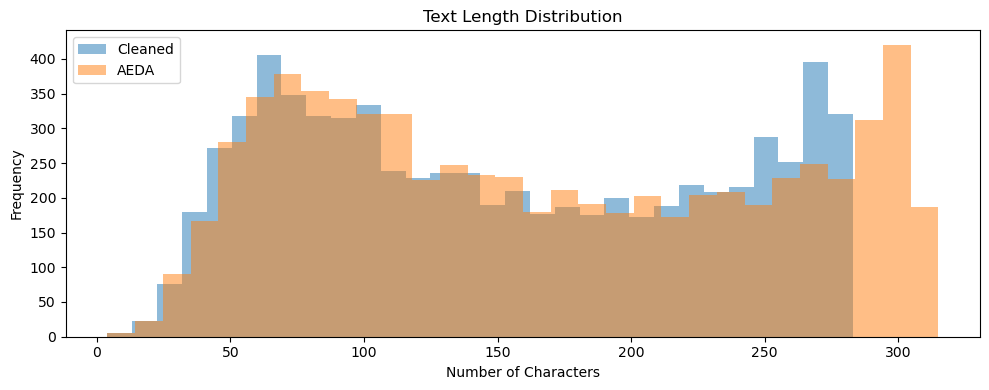

BLEU平均分: 0.523


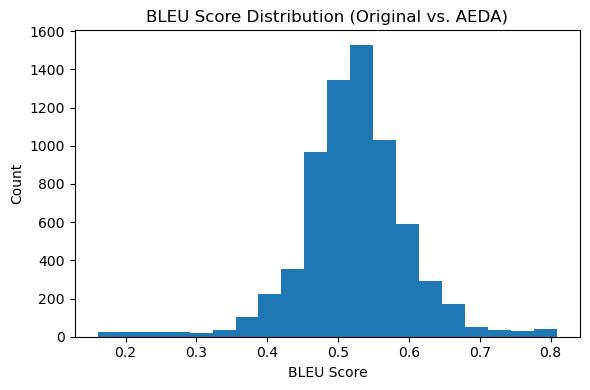


AEDA增强前后文本对比（展示5条）：
原文: 92321 the antiblackness and antiwomanism of the police desantis death cult false profits via
AEDA增强: 92321 ; ! the antiblackness and antiwomanism of the police ? desantis death cult false , profits via
----------------------------------------
原文: entiendo y comparto la queja de no tener como frente principal la aparición con vida de tehuel. pero si piensan que hablar de vih es falocentrismo y la verdad ojalá ni vayan mañana, gente horrenda.
AEDA增强: ! : entiendo y comparto la queja de no ? tener ; como frente principal la aparición con vida de tehuel. ! pero : si piensan que ? hablar de ? vih ! es ? falocentrismo y la verdad ojalá ni vayan mañana, gente horrenda.
----------------------------------------
原文: blessed? you think youre so damn funny but in reality you have penis envy. your whole life is consumed by byu. its ok to spate byu but yours isnt sports hate its hate hate, and if your president of muss that says a lot about the u.
AEDA增强: blessed? you think 

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 1. 基本统计
print(f"原始数据行数: {len(train_df)}")
print(f"AEDA增强数据行数: {len(df_aeda)}")
print(f"拼接后总行数: {len(df_all)}")

# 2. 标签分布
if 'label' in train_df.columns:
    plt.figure(figsize=(6, 4))
    train_df['label'].value_counts().plot(kind='bar')
    plt.title('Label Distribution (After Cleaning)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(train_df['label'].value_counts())

# 3. 文本长度
plt.figure(figsize=(10, 4))
train_df['cleaned_text'].str.len().plot(kind='hist', bins=30, alpha=0.5, label='Cleaned')
train_df['aug_aeda'].str.len().plot(kind='hist', bins=30, alpha=0.5, label='AEDA')
plt.legend()
plt.title('Text Length Distribution')
plt.xlabel('Number of Characters')
plt.tight_layout()
plt.show()

# 4. BLEU分数分布
bleu_scores = []
for orig, aug in zip(train_df['cleaned_text'], train_df['aug_aeda']):
    orig_tokens = orig.split()
    aug_tokens = aug.split()
    if len(orig_tokens) > 0 and len(aug_tokens) > 0:
        score = sentence_bleu([orig_tokens], aug_tokens, smoothing_function=SmoothingFunction().method1)
        bleu_scores.append(score)
    else:
        bleu_scores.append(np.nan)

print(f"BLEU平均分: {np.nanmean(bleu_scores):.3f}")

plt.figure(figsize=(6, 4))
plt.hist([s for s in bleu_scores if not np.isnan(s)], bins=20)
plt.title('BLEU Score Distribution (Original vs. AEDA)')
plt.xlabel('BLEU Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 5. 示例对比
print("\nAEDA增强前后文本对比（展示5条）：")
sample = train_df.sample(5)
for idx, row in sample.iterrows():
    print(f"原文: {row['cleaned_text']}")
    print(f"AEDA增强: {row['aug_aeda']}")
    print("-" * 40)

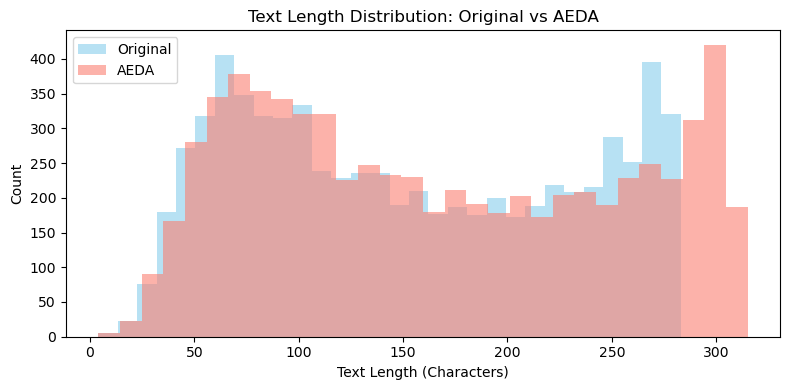

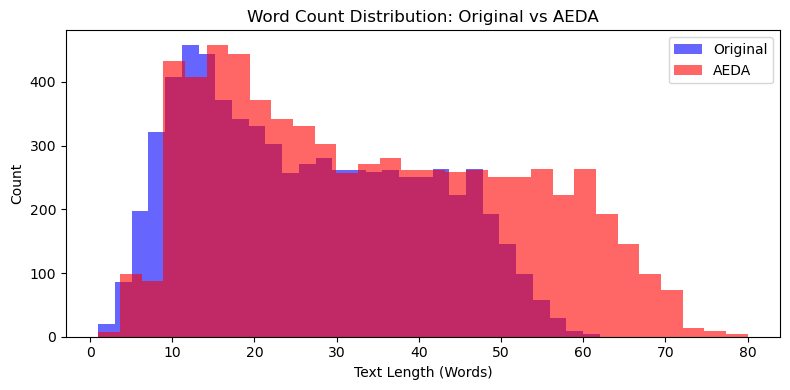

In [14]:
# 字符长度
train_df['orig_length'] = train_df['cleaned_text'].str.len()
train_df['aeda_length'] = train_df['aug_aeda'].str.len()

plt.figure(figsize=(8, 4))
plt.hist(train_df['orig_length'], bins=30, alpha=0.6, label='Original', color='skyblue')
plt.hist(train_df['aeda_length'], bins=30, alpha=0.6, label='AEDA', color='salmon')
plt.xlabel("Text Length (Characters)")
plt.ylabel("Count")
plt.title("Text Length Distribution: Original vs AEDA")
plt.legend()
plt.tight_layout()
plt.show()

# 单词长度
train_df['orig_word_count'] = train_df['cleaned_text'].apply(lambda x: len(x.split()))
train_df['aeda_word_count'] = train_df['aug_aeda'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(train_df['orig_word_count'], bins=30, alpha=0.6, label='Original', color='blue')
plt.hist(train_df['aeda_word_count'], bins=30, alpha=0.6, label='AEDA', color='red')
plt.xlabel("Text Length (Words)")
plt.ylabel("Count")
plt.title("Word Count Distribution: Original vs AEDA")
plt.legend()
plt.tight_layout()
plt.show()

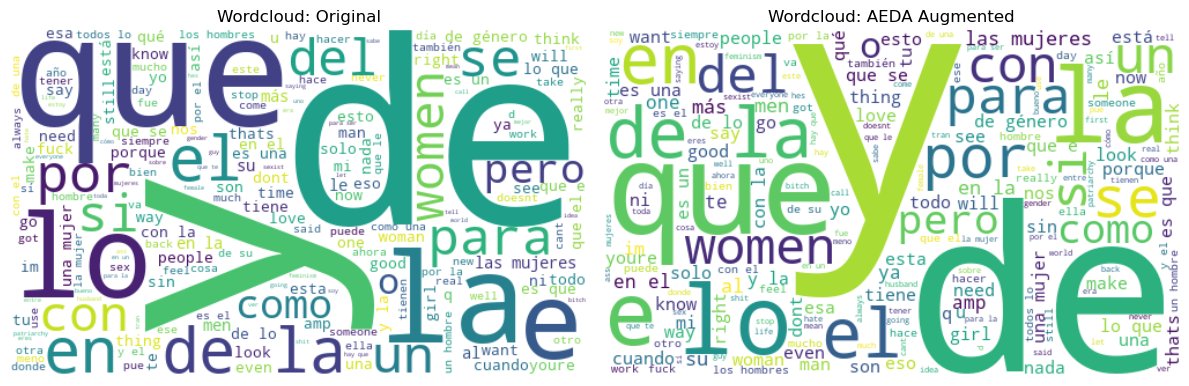

In [16]:
from wordcloud import WordCloud

text_original = ' '.join(train_df['cleaned_text'].dropna())
text_aeda = ' '.join(train_df['aug_aeda'].dropna())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
wc1 = WordCloud(width=500, height=300, background_color='white').generate(text_original)
plt.imshow(wc1, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud: Original")

plt.subplot(1,2,2)
wc2 = WordCloud(width=500, height=300, background_color='white').generate(text_aeda)
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud: AEDA Augmented")
plt.tight_layout()
plt.show()

In [19]:
orig_unique = train_df['cleaned_text'].nunique()
aeda_unique = train_df['aug_aeda'].nunique()
print(f"原文去重后唯一样本数: {orig_unique}")
print(f"AEDA增强后唯一样本数: {aeda_unique}")

原文去重后唯一样本数: 6899
AEDA增强后唯一样本数: 6920
